In [1]:
# Step 1: Import Required Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 2: Load the Dataset

from pathlib import Path

file_path = Path.home() / "OneDrive" / "Projects ML" / "Flight Fare Prediction" / "Flight_Fare.xlsx"

print("Checking file...")
print("File exists:", file_path.exists())

if file_path.exists():
    df = pd.read_excel(file_path)
    print("Dataset loaded successfully!")
else:
    print("Dataset file not found at:", file_path)

Checking file...
File exists: True
Dataset loaded successfully!


In [3]:
# Step 3: Check Dataset Dimensions

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 10683
Number of Columns: 11


In [4]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [6]:
# Step 5: Display All Column Names

print("Column Names:")
for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Column Names:
1 - Airline
2 - Date_of_Journey
3 - Source
4 - Destination
5 - Route
6 - Dep_Time
7 - Arrival_Time
8 - Duration
9 - Total_Stops
10 - Additional_Info
11 - Price


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
# Step 7: Check Missing Values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


In [9]:
# Step 8: Inspect Rows with Missing Values

missing_rows = df[df.isnull().any(axis=1)]

missing_rows

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [10]:
# Step 9: Calculate Missing Value Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage[missing_percentage > 0])

Missing Value Percentage:
Route          0.009361
Total_Stops    0.009361
dtype: float64


In [11]:
# Step 10: Check Duplicate Records

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 220


In [12]:
# Step 11: Inspect Duplicate Records

duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
33,Jet Airways,15/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,12:35 16 Jun,22h,2 stops,In-flight meal not included,10919
49,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150
73,Jet Airways,24/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 25 Jun,13h 30m,2 stops,No info,12819
81,Jet Airways,24/03/2019,Banglore,New Delhi,BLR → DEL,19:55,22:35,2h 40m,non-stop,No info,7229
87,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,04:25 07 Jun,18h 45m,2 stops,No info,13014
136,Jet Airways,6/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,06:45,04:25 07 Jun,21h 40m,2 stops,No info,13376
137,Air India,27/06/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 28 Jun,21h 15m,2 stops,No info,10441
209,Jet Airways,18/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,04:25 20 May,29h 20m,2 stops,No info,15129
224,Jet Airways,9/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 10 Jun,22h 55m,2 stops,No info,13014
251,Air India,1/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:45,19:15 02 Jun,23h 30m,2 stops,No info,10651


In [13]:
# Step 12: Remove Duplicate Records

rows_before = df.shape[0]

df = df.drop_duplicates()

rows_after = df.shape[0]

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicate rows removed:", rows_before - rows_after)

Rows before removing duplicates: 10683
Rows after removing duplicates: 10463
Duplicate rows removed: 220


In [14]:
# Step 13: Recheck Missing Values After Removing Duplicates

missing_after_duplicates = df.isnull().sum()

print("Missing Values After Removing Duplicates:")
print(missing_after_duplicates[missing_after_duplicates > 0])

Missing Values After Removing Duplicates:
Route          1
Total_Stops    1
dtype: int64


In [15]:
# Step 14: Remove Rows with Missing Values

rows_before_missing = df.shape[0]

df = df.dropna()

rows_after_missing = df.shape[0]

print("Rows before removing missing values:", rows_before_missing)
print("Rows after removing missing values:", rows_after_missing)
print("Rows removed:", rows_before_missing - rows_after_missing)

Rows before removing missing values: 10463
Rows after removing missing values: 10462
Rows removed: 1


In [16]:
# Step 15: Validate the Cleaned Dataset

print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

Remaining missing values: 0
Remaining duplicate rows: 0
Final dataset shape: (10462, 11)


In [17]:
df.describe()

,Price
count,10462.000000
mean,9026.790289
std,4624.849541
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12344.750000
max,79512.000000


In [18]:
# Step 17: Check Unique Categories

categorical_columns = [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops',
    'Additional_Info'
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print("Number of unique values:", df[column].nunique())
    print(df[column].value_counts())


Airline
Number of unique values: 12
Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

Source
Number of unique values: 5
Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

Destination
Number of unique values: 6
Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

Total_Stops
Number of unique values: 5
Total_Stops
1 stop      5625
non-stop    3475


In [19]:
# Step 18: Standardize Additional_Info Categories

df['Additional_Info'] = df['Additional_Info'].replace({
    'No Info': 'No info'
})

print("Unique Additional_Info values after standardization:")
print(df['Additional_Info'].value_counts())

Unique Additional_Info values after standardization:
Additional_Info
No info                         8185
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64


In [20]:
# Step 19: Check Unique Values in Categorical Columns

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print("Number of unique values:", df[column].nunique())
    print(df[column].value_counts())


Airline
Number of unique values: 12
Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

Date_of_Journey
Number of unique values: 44
Date_of_Journey
6/06/2019     490
18/05/2019    486
9/06/2019     485
12/06/2019    483
21/05/2019    482
9/05/2019     466
21/03/2019    412
15/05/2019    402
27/05/2019    369
27/06/2019    339
24/06/2019    330
1/06/2019     330
3/06/2019     326
15/06/2019    314
24/03/2019    314
6/03/2019     302
27/03/2019    290
24/05/2019    286
6/05/2019     281
1/05/2019     274
12/0

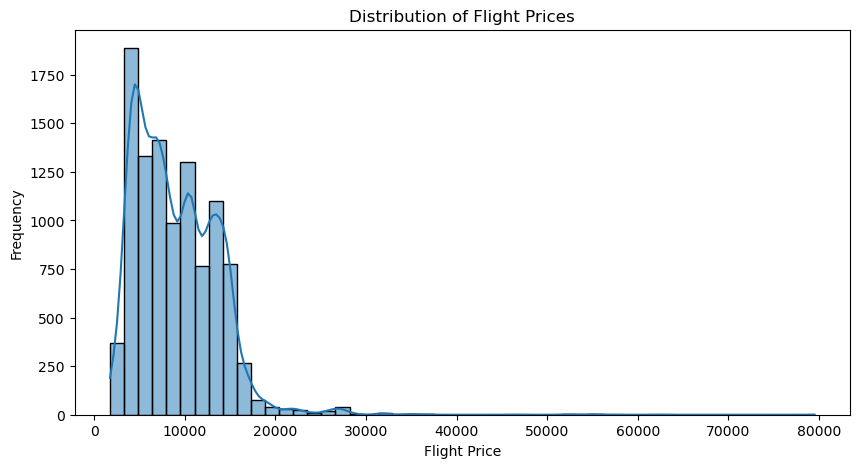

In [21]:
# Step 20: Distribution of Flight Prices

plt.figure(figsize=(10, 5))

sns.histplot(df['Price'], bins=50, kde=True)

plt.title('Distribution of Flight Prices')
plt.xlabel('Flight Price')
plt.ylabel('Frequency')

plt.show()

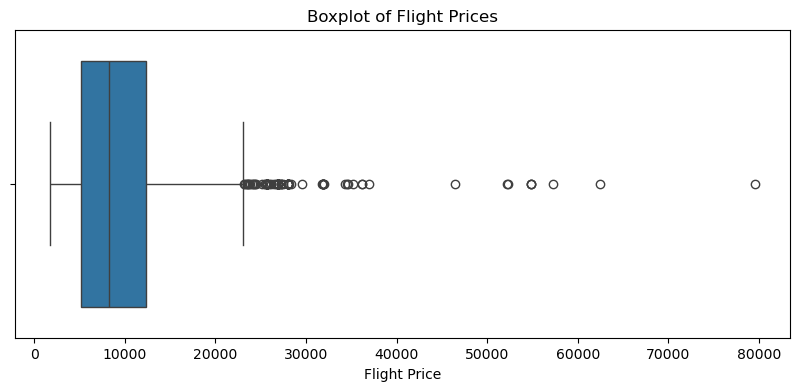

In [22]:
# Step 21: Boxplot of Flight Prices

plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Price'])

plt.title('Boxplot of Flight Prices')
plt.xlabel('Flight Price')

plt.show()

In [23]:
# Step 22: Identify Potential Price Outliers Using IQR

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Price'] < lower_bound) |
    (df['Price'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Potential Outliers:", len(outliers))
print("Percentage of Potential Outliers:", 
      round((len(outliers) / len(df)) * 100, 2), "%")

Q1: 5224.0
Q3: 12344.75
IQR: 7120.75
Lower Bound: -5457.125
Upper Bound: 23025.875
Number of Potential Outliers: 94
Percentage of Potential Outliers: 0.9 %


In [24]:
# Step 23: Inspect Potential High-Price Records

high_price_records = df[df['Price'] > upper_bound].copy()

high_price_records[
    ['Airline', 'Source', 'Destination', 'Total_Stops',
     'Additional_Info', 'Price']
].sort_values('Price', ascending=False).head(20)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price
2924,Jet Airways Business,Banglore,New Delhi,1 stop,Business class,79512
5372,Jet Airways Business,Banglore,New Delhi,1 stop,Business class,62427
10364,Jet Airways Business,Banglore,New Delhi,1 stop,Business class,57209
1478,Jet Airways,Banglore,New Delhi,1 stop,No info,54826
5439,Jet Airways,Banglore,New Delhi,1 stop,No info,54826
2618,Jet Airways,Banglore,New Delhi,1 stop,No info,54826
9715,Jet Airways Business,Delhi,Cochin,2 stops,No info,52285
657,Jet Airways Business,Banglore,New Delhi,1 stop,No info,52229
7351,Jet Airways Business,Delhi,Cochin,2 stops,No info,46490
396,Multiple carriers,Delhi,Cochin,1 stop,No info,36983


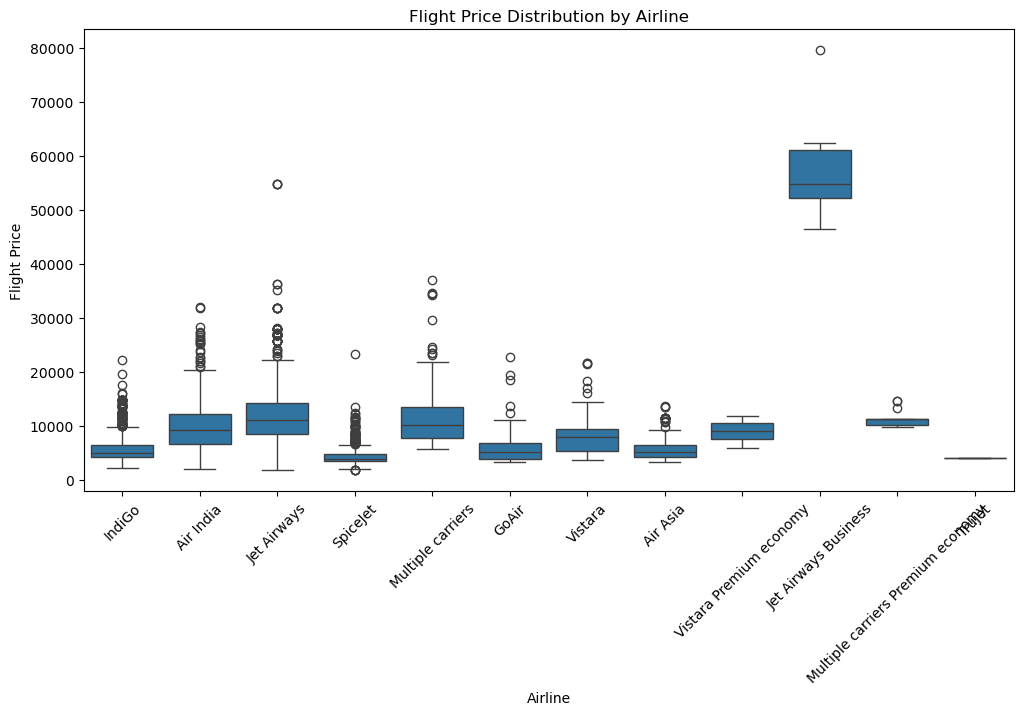

In [25]:
# Step 24: Flight Price by Airline

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Airline',
    y='Price'
)

plt.title('Flight Price Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Flight Price')
plt.xticks(rotation=45)

plt.show()

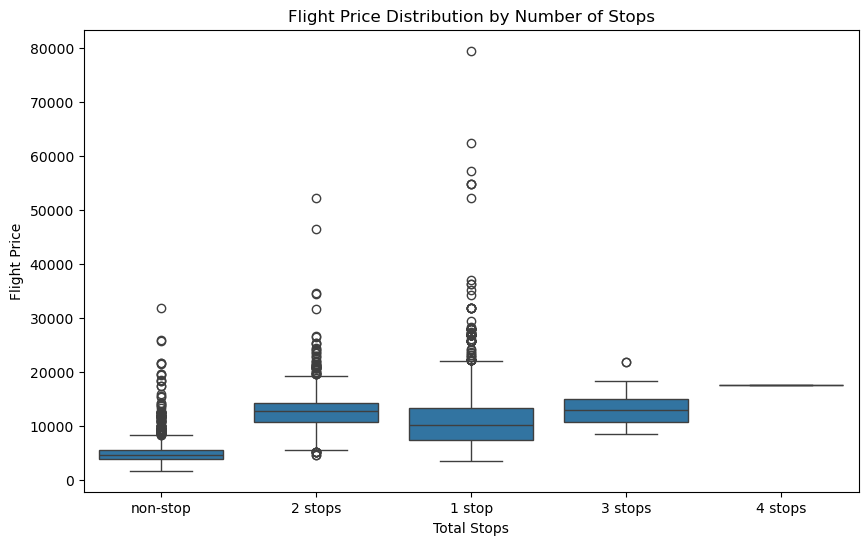

In [26]:
# Step 25: Flight Price by Total Stops

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Total_Stops',
    y='Price'
)

plt.title('Flight Price Distribution by Number of Stops')
plt.xlabel('Total Stops')
plt.ylabel('Flight Price')

plt.show()

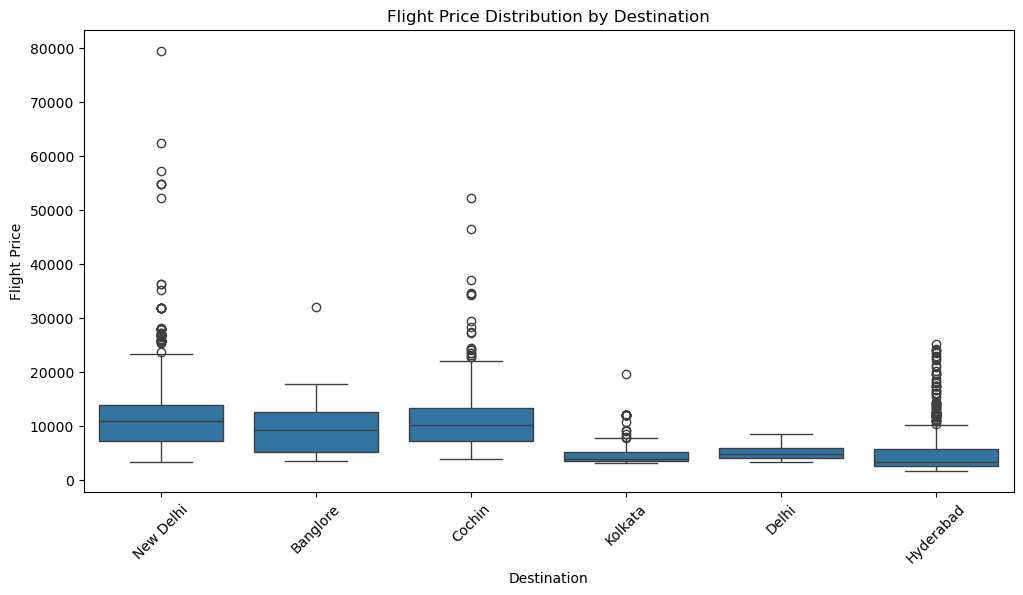

In [27]:
# Step 26: Flight Price Distribution by Destination

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Destination',
    y='Price'
)

plt.title('Flight Price Distribution by Destination')
plt.xlabel('Destination')
plt.ylabel('Flight Price')
plt.xticks(rotation=45)

plt.show()

In [28]:
# Step 27: Average Flight Price by Destination

avg_price_destination = df.groupby('Destination')['Price'].mean().sort_values(ascending=False)

print("Average Flight Price by Destination:")
print(avg_price_destination)

Average Flight Price by Destination:
Destination
New Delhi    12007.421225
Cochin       10461.600690
Banglore      9143.083566
Delhi         5143.918577
Hyderabad     5059.708752
Kolkata       4789.892388
Name: Price, dtype: float64


In [29]:
# Step 28: Average Flight Price by Airline

avg_price_airline = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)

print("Average Flight Price by Airline:")
print(avg_price_airline)

Average Flight Price by Airline:
Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9556.608028
Vistara Premium economy               8962.333333
Vistara                               7801.355649
GoAir                                 5861.056701
IndiGo                                5668.469897
Air Asia                              5590.260188
SpiceJet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64


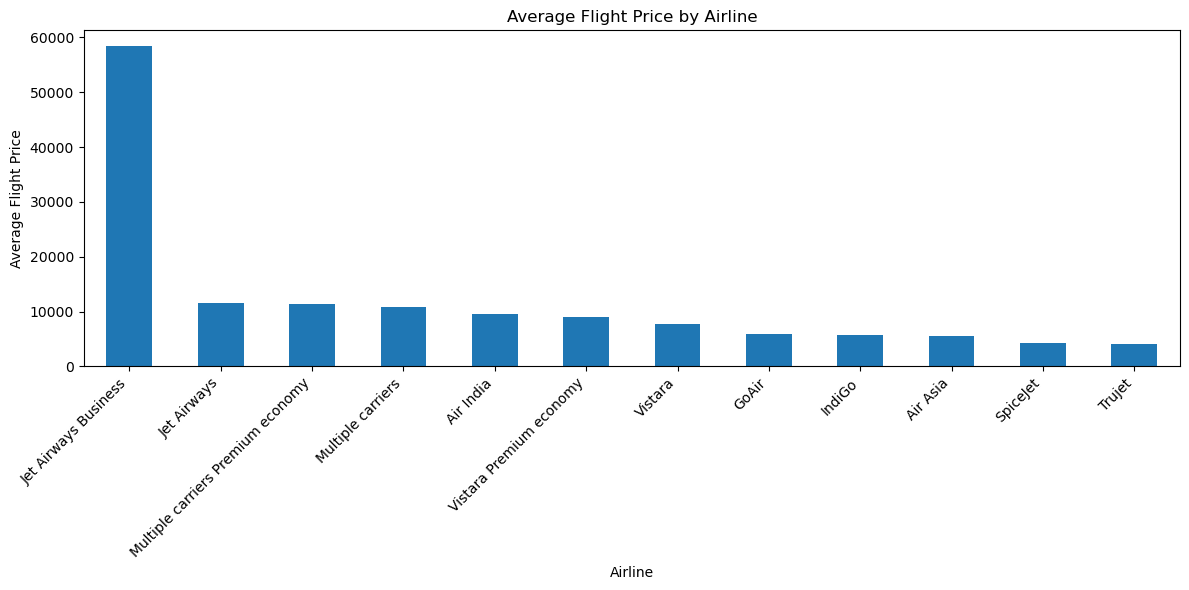

In [30]:
# Step 29: Average Flight Price by Airline - Bar Chart

plt.figure(figsize=(12, 6))

avg_price_airline.plot(kind='bar')

plt.title('Average Flight Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Flight Price')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [31]:
# Step 30: Average Flight Price by Number of Stops

avg_price_stops = df.groupby('Total_Stops')['Price'].mean().sort_values(ascending=False)

print("Average Flight Price by Number of Stops:")
print(avg_price_stops)

Average Flight Price by Number of Stops:
Total_Stops
4 stops     17686.000000
3 stops     13260.674419
2 stops     12761.099393
1 stop      10594.123556
non-stop     5018.506763
Name: Price, dtype: float64


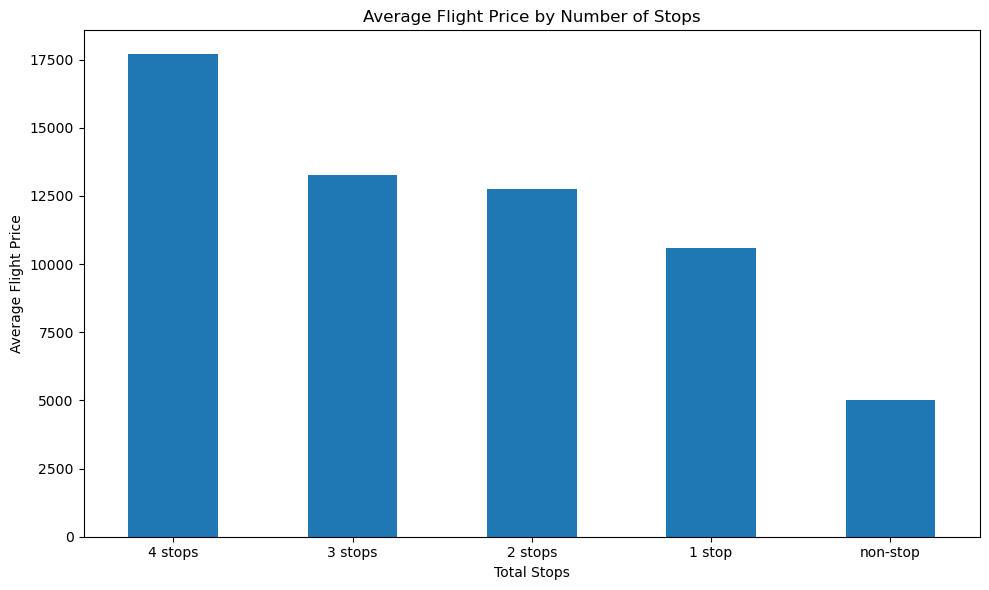

In [32]:
# Step 31: Average Flight Price by Number of Stops - Bar Chart

plt.figure(figsize=(10, 6))

avg_price_stops.plot(kind='bar')

plt.title('Average Flight Price by Number of Stops')
plt.xlabel('Total Stops')
plt.ylabel('Average Flight Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
# Step 32: Average Flight Price by Source

avg_price_source = df.groupby('Source')['Price'].mean().sort_values(ascending=False)

print("Average Flight Price by Source:")
print(avg_price_source)

Average Flight Price by Source:
Source
Delhi       10461.600690
Kolkata      9143.083566
Banglore     8022.872877
Mumbai       5059.708752
Chennai      4789.892388
Name: Price, dtype: float64


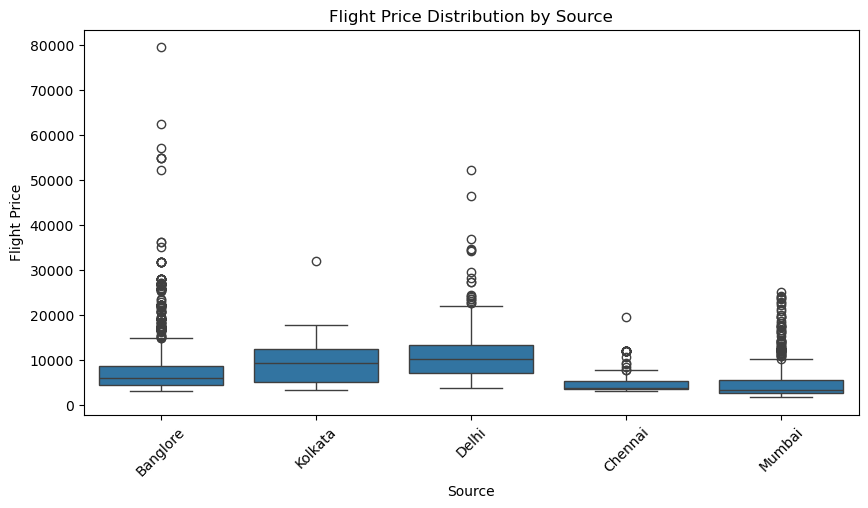

In [34]:
# Step 33: Flight Price Distribution by Source

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Source',
    y='Price'
)

plt.title('Flight Price Distribution by Source')
plt.xlabel('Source')
plt.ylabel('Flight Price')
plt.xticks(rotation=45)

plt.show()

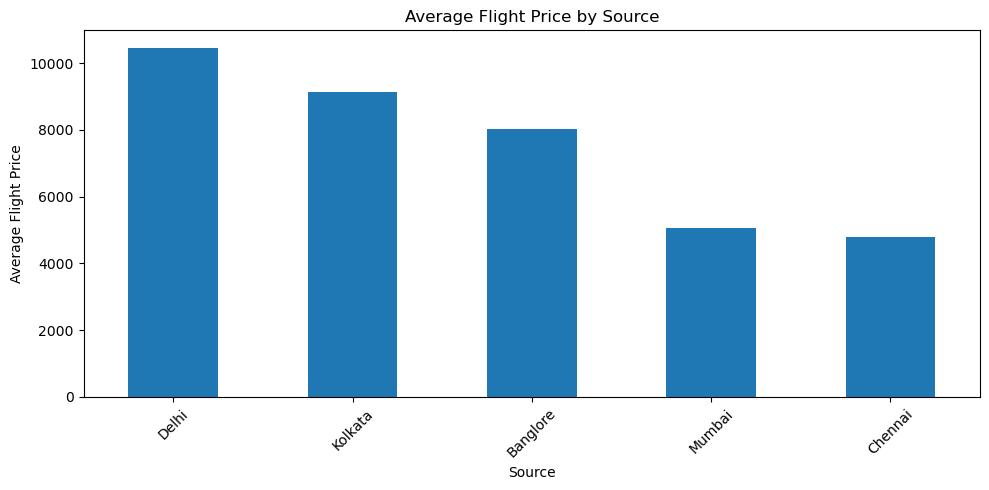

In [35]:
# Step 34: Average Flight Price by Source - Bar Chart

plt.figure(figsize=(10, 5))

avg_price_source.plot(kind='bar')

plt.title('Average Flight Price by Source')
plt.xlabel('Source')
plt.ylabel('Average Flight Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
# Step 35: Average Flight Price by Departure Time

avg_price_departure = (
    df.groupby('Dep_Time')['Price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Flight Price by Departure Time:")
print(avg_price_departure)

Average Flight Price by Departure Time:
Dep_Time
18:40    23872.333333
03:00    22294.000000
17:50    19493.923077
00:20    18635.333333
08:40    18559.666667
             ...     
14:45     3658.411765
13:10     3617.250000
19:05     3012.000000
01:40     2754.000000
22:45     2293.750000
Name: Price, Length: 222, dtype: float64


In [37]:
# Step 36: Create Departure Time Categories

def departure_period(time):
    hour = int(time.split(':')[0])
    
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Departure_Period'] = df['Dep_Time'].apply(departure_period)

print("Number of flights by Departure Period:")
print(df['Departure_Period'].value_counts())

Number of flights by Departure Period:
Departure_Period
Morning      4806
Evening      2323
Afternoon    1874
Night        1459
Name: count, dtype: int64


In [38]:
# Step 37: Average Flight Price by Departure Period

avg_price_departure_period = (
    df.groupby('Departure_Period')['Price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Flight Price by Departure Period:")
print(avg_price_departure_period)

Average Flight Price by Departure Period:
Departure_Period
Afternoon    9347.554963
Evening      9149.874731
Morning      9140.543279
Night        8044.106923
Name: Price, dtype: float64


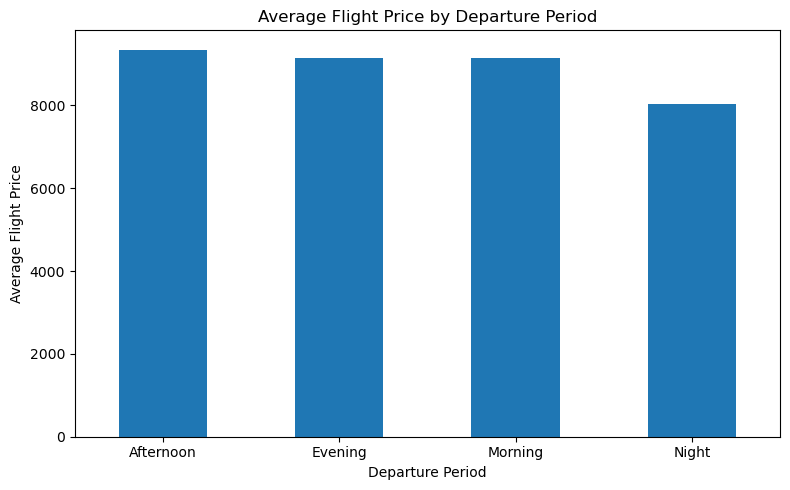

In [39]:
# Step 38: Average Flight Price by Departure Period - Bar Chart

plt.figure(figsize=(8, 5))

avg_price_departure_period.plot(kind='bar')

plt.title('Average Flight Price by Departure Period')
plt.xlabel('Departure Period')
plt.ylabel('Average Flight Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [40]:
# Step 39: Create Arrival Time Categories

def arrival_period(time):
    hour = int(time.split(':')[0])
    
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Arrival_Period'] = df['Arrival_Time'].apply(arrival_period)

print("Number of flights by Arrival Period:")
print(df['Arrival_Period'].value_counts())

Number of flights by Arrival Period:
Arrival_Period
Night        3562
Evening      2631
Morning      2259
Afternoon    2010
Name: count, dtype: int64


In [41]:
# Step 40: Average Flight Price by Arrival Period

avg_price_arrival_period = (
    df.groupby('Arrival_Period')['Price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Flight Price by Arrival Period:")
print(avg_price_arrival_period)

Average Flight Price by Arrival Period:
Arrival_Period
Evening      10119.762068
Night         8825.463223
Afternoon     8710.256716
Morning       8352.930500
Name: Price, dtype: float64


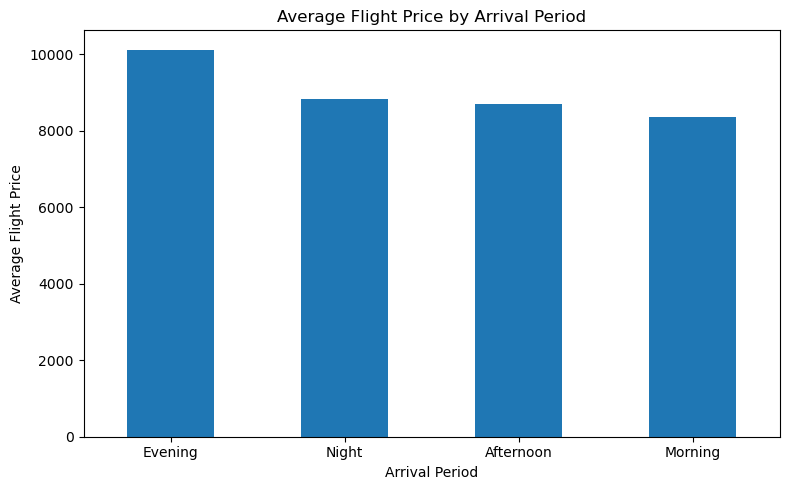

In [42]:
# Step 41: Average Flight Price by Arrival Period - Bar Chart

plt.figure(figsize=(8, 5))

avg_price_arrival_period.plot(kind='bar')

plt.title('Average Flight Price by Arrival Period')
plt.xlabel('Arrival Period')
plt.ylabel('Average Flight Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [43]:
# Step 42: Convert Duration into Total Minutes

def duration_to_minutes(duration):
    hours = 0
    minutes = 0

    parts = duration.split()

    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
        elif 'm' in part:
            minutes = int(part.replace('m', ''))

    return hours * 60 + minutes


df['Duration_Minutes'] = df['Duration'].apply(duration_to_minutes)

print("Duration converted to minutes successfully.")
print(df[['Duration', 'Duration_Minutes']].head())

Duration converted to minutes successfully.
  Duration  Duration_Minutes
0   2h 50m               170
1   7h 25m               445
2      19h              1140
3   5h 25m               325
4   4h 45m               285


In [44]:
# Step 43: Descriptive Statistics of Flight Duration

print("Flight Duration Statistics:")
print(df['Duration_Minutes'].describe())

Flight Duration Statistics:
count    10462.000000
mean       629.781591
std        500.699045
min          5.000000
25%        170.000000
50%        505.000000
75%        910.000000
max       2860.000000
Name: Duration_Minutes, dtype: float64


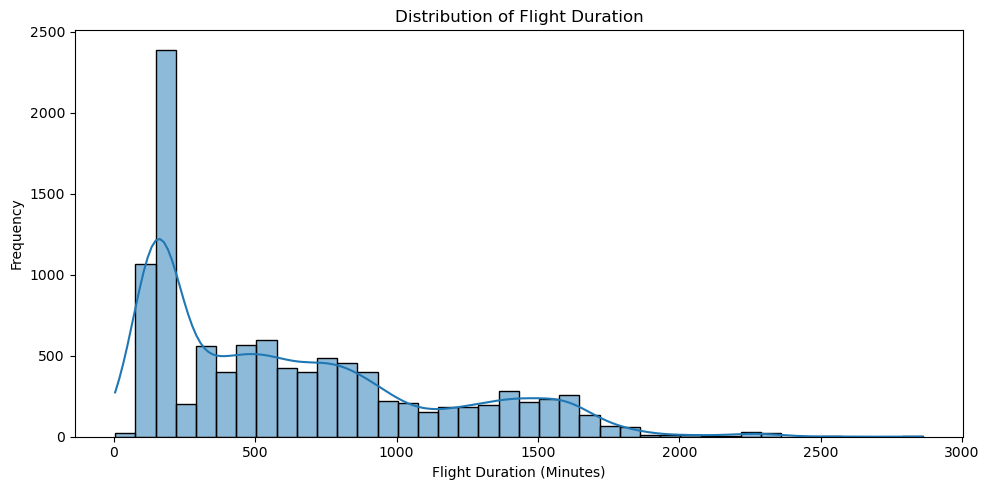

In [45]:
# Step 44: Distribution of Flight Duration

plt.figure(figsize=(10, 5))

sns.histplot(df['Duration_Minutes'], bins=40, kde=True)

plt.title('Distribution of Flight Duration')
plt.xlabel('Flight Duration (Minutes)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

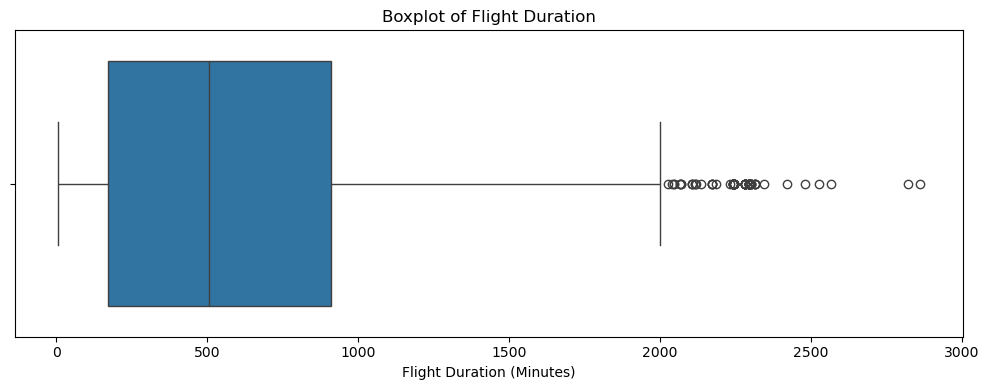

In [46]:
# Step 45: Boxplot of Flight Duration

plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Duration_Minutes'])

plt.title('Boxplot of Flight Duration')
plt.xlabel('Flight Duration (Minutes)')

plt.tight_layout()
plt.show()

In [47]:
# Step 46: Identify Potential Duration Outliers Using IQR

Q1_duration = df['Duration_Minutes'].quantile(0.25)
Q3_duration = df['Duration_Minutes'].quantile(0.75)

IQR_duration = Q3_duration - Q1_duration

lower_bound_duration = Q1_duration - 1.5 * IQR_duration
upper_bound_duration = Q3_duration + 1.5 * IQR_duration

duration_outliers = df[
    (df['Duration_Minutes'] < lower_bound_duration) |
    (df['Duration_Minutes'] > upper_bound_duration)
]

print("Q1:", Q1_duration)
print("Q3:", Q3_duration)
print("IQR:", IQR_duration)
print("Lower Bound:", lower_bound_duration)
print("Upper Bound:", upper_bound_duration)
print("Number of Potential Duration Outliers:", len(duration_outliers))
print(
    "Percentage of Potential Duration Outliers:",
    round((len(duration_outliers) / len(df)) * 100, 2),
    "%"
)

Q1: 170.0
Q3: 910.0
IQR: 740.0
Lower Bound: -940.0
Upper Bound: 2020.0
Number of Potential Duration Outliers: 75
Percentage of Potential Duration Outliers: 0.72 %


In [49]:
# Step 47: Inspect Potential Duration Outliers

print("Columns available in duration_outliers:")
print(duration_outliers.columns.tolist())

Columns available in duration_outliers:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Departure_Period', 'Arrival_Period', 'Duration_Minutes']


In [51]:
# Step 47: Inspect Potential Duration Outliers

print("Potential Duration Outliers:")

display(
    duration_outliers[
        ['Airline',
         'Source',
         'Destination',
         'Total_Stops',
         'Duration_Minutes',
         'Price']
    ].sort_values(
        'Duration_Minutes',
        ascending=False
    )
)

Potential Duration Outliers:


,Airline,Source,Destination,Total_Stops,Duration_Minutes,Price
10456,Jet Airways,Delhi,Cochin,2 stops,2860,20694
1067,Jet Airways,Delhi,Cochin,2 stops,2820,20064
8409,Jet Airways,Delhi,Cochin,2 stops,2565,12819
5953,Jet Airways,Delhi,Cochin,2 stops,2525,11664
7906,Air India,Kolkata,Banglore,2 stops,2480,13990
...,...,...,...,...,...,...
2980,Air India,Kolkata,Banglore,2 stops,2065,10991
7626,Jet Airways,Delhi,Cochin,2 stops,2045,20747
470,Jet Airways,Delhi,Cochin,2 stops,2045,13082
3152,Jet Airways,Delhi,Cochin,2 stops,2040,12347


In [52]:
# Step 48: Summary of Potential Duration Outliers

print("Potential Duration Outlier Summary:")
print("Number of outliers:", len(duration_outliers))
print("Minimum Duration:", duration_outliers['Duration_Minutes'].min(), "minutes")
print("Maximum Duration:", duration_outliers['Duration_Minutes'].max(), "minutes")
print("Average Duration:", round(duration_outliers['Duration_Minutes'].mean(), 2), "minutes")

print("\nOutliers by Airline:")
print(duration_outliers['Airline'].value_counts())

print("\nOutliers by Total Stops:")
print(duration_outliers['Total_Stops'].value_counts())

Potential Duration Outlier Summary:
Number of outliers: 75
Minimum Duration: 2025 minutes
Maximum Duration: 2860 minutes
Average Duration: 2257.27 minutes

Outliers by Airline:
Airline
Air India      50
Jet Airways    25
Name: count, dtype: int64

Outliers by Total Stops:
Total_Stops
2 stops    61
3 stops    14
Name: count, dtype: int64


In [53]:
# Step 49: Detailed Inspection of Duration Outliers

print("Detailed Duration Outlier Inspection:")

display(
    duration_outliers[
        ['Airline', 'Source', 'Destination',
         'Total_Stops', 'Duration', 'Duration_Minutes', 'Price']
    ].sort_values('Duration_Minutes', ascending=False)
)

Detailed Duration Outlier Inspection:


,Airline,Source,Destination,Total_Stops,Duration,Duration_Minutes,Price
10456,Jet Airways,Delhi,Cochin,2 stops,47h 40m,2860,20694
1067,Jet Airways,Delhi,Cochin,2 stops,47h,2820,20064
8409,Jet Airways,Delhi,Cochin,2 stops,42h 45m,2565,12819
5953,Jet Airways,Delhi,Cochin,2 stops,42h 5m,2525,11664
7906,Air India,Kolkata,Banglore,2 stops,41h 20m,2480,13990
...,...,...,...,...,...,...,...
2980,Air India,Kolkata,Banglore,2 stops,34h 25m,2065,10991
7626,Jet Airways,Delhi,Cochin,2 stops,34h 5m,2045,20747
470,Jet Airways,Delhi,Cochin,2 stops,34h 5m,2045,13082
3152,Jet Airways,Delhi,Cochin,2 stops,34h,2040,12347


In [54]:
# Step 50: Analyze Duration Outliers by Route and Number of Stops

print("Duration Outliers by Route:")
print(
    duration_outliers.groupby(
        ['Source', 'Destination', 'Total_Stops']
    )['Duration_Minutes']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Duration Outliers by Route:
                                  count   min   max         mean
Source   Destination Total_Stops                                
Delhi    Cochin      2 stops         47  2040  2860  2272.021277
                     3 stops         11  2280  2280  2280.000000
Banglore New Delhi   2 stops          8  2025  2420  2216.875000
Kolkata  Banglore    2 stops          4  2065  2480  2213.750000
                     3 stops          2  2115  2115  2115.000000
Mumbai   Hyderabad   2 stops          2  2245  2245  2245.000000
Banglore New Delhi   3 stops          1  2120  2120  2120.000000


In [55]:
print("\nDuration Outliers by Airline and Number of Stops:")
print(
    duration_outliers.groupby(
        ['Airline', 'Total_Stops']
    )['Duration_Minutes']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)


Duration Outliers by Airline and Number of Stops:
                         count   min   max         mean
Airline     Total_Stops                                
Air India   2 stops         36  2025  2480  2239.722222
Jet Airways 2 stops         25  2040  2860  2289.400000
Air India   3 stops         14  2115  2280  2245.000000


In [56]:
# Step 51: Verify Duration Conversion for Potential Outliers

print("Checking Duration Conversion for Potential Outliers:")

display(
    duration_outliers[
        ['Airline', 'Source', 'Destination',
         'Total_Stops', 'Duration', 'Duration_Minutes']
    ].sort_values('Duration_Minutes', ascending=False)
)

Checking Duration Conversion for Potential Outliers:


,Airline,Source,Destination,Total_Stops,Duration,Duration_Minutes
10456,Jet Airways,Delhi,Cochin,2 stops,47h 40m,2860
1067,Jet Airways,Delhi,Cochin,2 stops,47h,2820
8409,Jet Airways,Delhi,Cochin,2 stops,42h 45m,2565
5953,Jet Airways,Delhi,Cochin,2 stops,42h 5m,2525
7906,Air India,Kolkata,Banglore,2 stops,41h 20m,2480
...,...,...,...,...,...,...
2980,Air India,Kolkata,Banglore,2 stops,34h 25m,2065
7626,Jet Airways,Delhi,Cochin,2 stops,34h 5m,2045
470,Jet Airways,Delhi,Cochin,2 stops,34h 5m,2045
3152,Jet Airways,Delhi,Cochin,2 stops,34h,2040


In [ ]:
### Duration Outlier Analysis – Conclusion

The IQR method identified 75 potential outliers in flight duration, representing approximately 0.72% of the dataset. The identified records have durations ranging from 2025 to 2860 minutes.

Further inspection showed that these observations are mainly associated with flights having 2 or 3 stops. The original Duration values were also verified against the calculated Duration_Minutes values, and the conversions were found to be consistent.

Therefore, these observations are considered potential but plausible long-duration flights rather than confirmed data-entry errors. They are retained in the dataset to avoid losing potentially meaningful information.

In [57]:
# Step 53: Identify Potential Price Outliers Using IQR

Q1_price = df['Price'].quantile(0.25)
Q3_price = df['Price'].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

price_outliers = df[
    (df['Price'] < lower_bound_price) |
    (df['Price'] > upper_bound_price)
]

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower Bound:", lower_bound_price)
print("Upper Bound:", upper_bound_price)
print("Number of Potential Price Outliers:", len(price_outliers))
print(
    "Percentage of Potential Price Outliers:",
    round((len(price_outliers) / len(df)) * 100, 2),
    "%"
)

Q1: 5224.0
Q3: 12344.75
IQR: 7120.75
Lower Bound: -5457.125
Upper Bound: 23025.875
Number of Potential Price Outliers: 94
Percentage of Potential Price Outliers: 0.9 %


In [58]:
# Step 54: Inspect Potential Price Outliers

print("Potential Price Outliers:")

display(
    price_outliers[
        ['Airline', 'Source', 'Destination',
         'Total_Stops', 'Duration',
         'Duration_Minutes', 'Price']
    ].sort_values('Price', ascending=False)
)

Potential Price Outliers:


,Airline,Source,Destination,Total_Stops,Duration,Duration_Minutes,Price
2924,Jet Airways Business,Banglore,New Delhi,1 stop,5h 40m,340,79512
5372,Jet Airways Business,Banglore,New Delhi,1 stop,6h 40m,400,62427
10364,Jet Airways Business,Banglore,New Delhi,1 stop,4h 40m,280,57209
1478,Jet Airways,Banglore,New Delhi,1 stop,6h 5m,365,54826
5439,Jet Airways,Banglore,New Delhi,1 stop,6h 5m,365,54826
...,...,...,...,...,...,...,...
1196,Multiple carriers,Delhi,Cochin,2 stops,7h 45m,465,23583
1341,Multiple carriers,Delhi,Cochin,1 stop,6h 35m,395,23533
8990,Jet Airways,Mumbai,Hyderabad,2 stops,10h 5m,605,23528
5136,SpiceJet,Banglore,New Delhi,1 stop,7h 55m,475,23267


In [59]:
# Step 55: Analyze Price Outliers by Airline and Number of Stops

print("Price Outliers by Airline:")
print(
    price_outliers['Airline']
    .value_counts()
)

print("\nPrice Outliers by Total Stops:")
print(
    price_outliers['Total_Stops']
    .value_counts()
)

Price Outliers by Airline:
Airline
Jet Airways             62
Air India               15
Multiple carriers       10
Jet Airways Business     6
SpiceJet                 1
Name: count, dtype: int64

Price Outliers by Total Stops:
Total_Stops
1 stop      75
2 stops     16
non-stop     3
Name: count, dtype: int64


In [60]:
# Step 56: Price Outlier Statistics by Airline

print("Price Outlier Statistics by Airline:")

display(
    price_outliers.groupby('Airline')['Price']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Price Outlier Statistics by Airline:


,count,min,max,mean
Airline,,,,
Jet Airways,62,23528,54826,28966.677419
Air India,15,23677,31945,26759.066667
Multiple carriers,10,23170,36983,28902.700000
Jet Airways Business,6,46490,79512,58358.666667
SpiceJet,1,23267,23267,23267.000000


In [61]:
# Step 57: Price Outliers by Route

print("Price Outliers by Route:")

print(
    price_outliers.groupby(
        ['Source', 'Destination', 'Total_Stops']
    )['Price']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Price Outliers by Route:
                                  count    min    max          mean
Source   Destination Total_Stops                                   
Banglore New Delhi   1 stop          65  23267  79512  31148.476923
Delhi    Cochin      1 stop          10  23170  36983  27885.600000
                     2 stops          6  23583  52285  35999.500000
Banglore New Delhi   2 stops          5  25430  31783  27173.200000
Mumbai   Hyderabad   2 stops          5  23528  25139  24167.000000
Banglore New Delhi   non-stop         2  25703  25913  25808.000000
Kolkata  Banglore    non-stop         1  31945  31945  31945.000000


In [62]:
# Step 58: Price Outliers by Airline and Number of Stops

print("Price Outliers by Airline and Number of Stops:")

print(
    price_outliers.groupby(
        ['Airline', 'Total_Stops']
    )['Price']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Price Outliers by Airline and Number of Stops:
                                  count    min    max          mean
Airline              Total_Stops                                   
Jet Airways          1 stop          58  25735  54826  29314.448276
Air India            1 stop           6  23677  28322  26136.666667
                     2 stops          6  25139  31783  26834.166667
Multiple carriers    1 stop           6  23170  36983  28634.166667
Jet Airways          2 stops          4  23528  24210  23924.000000
Jet Airways Business 1 stop           4  52229  79512  62844.250000
Multiple carriers    2 stops          4  23583  34608  29305.500000
Air India            non-stop         3  25703  31945  27853.666667
Jet Airways Business 2 stops          2  46490  52285  49387.500000
SpiceJet             1 stop           1  23267  23267  23267.000000


In [63]:
# Step 59: Summary of Potential Price Outliers

print("Potential Price Outlier Summary:")

print("Number of outliers:", len(price_outliers))

print(
    "Minimum Price:",
    price_outliers['Price'].min(),
    "₹"
)

print(
    "Maximum Price:",
    price_outliers['Price'].max(),
    "₹"
)

print(
    "Average Price:",
    round(price_outliers['Price'].mean(), 2),
    "₹"
)

print("\nOutliers by Airline:")
print(price_outliers['Airline'].value_counts())

print("\nOutliers by Total Stops:")
print(price_outliers['Total_Stops'].value_counts())

Potential Price Outlier Summary:
Number of outliers: 94
Minimum Price: 23170 ₹
Maximum Price: 79512 ₹
Average Price: 30423.04 ₹

Outliers by Airline:
Airline
Jet Airways             62
Air India               15
Multiple carriers       10
Jet Airways Business     6
SpiceJet                 1
Name: count, dtype: int64

Outliers by Total Stops:
Total_Stops
1 stop      75
2 stops     16
non-stop     3
Name: count, dtype: int64


In [64]:
# Step 60: Detailed Inspection of Price Outliers

print("Detailed Price Outlier Inspection:")

display(
    price_outliers[
        ['Airline', 'Source', 'Destination',
         'Total_Stops', 'Duration', 'Duration_Minutes', 'Price']
    ]
    .sort_values('Price', ascending=False)
)

Detailed Price Outlier Inspection:


,Airline,Source,Destination,Total_Stops,Duration,Duration_Minutes,Price
2924,Jet Airways Business,Banglore,New Delhi,1 stop,5h 40m,340,79512
5372,Jet Airways Business,Banglore,New Delhi,1 stop,6h 40m,400,62427
10364,Jet Airways Business,Banglore,New Delhi,1 stop,4h 40m,280,57209
1478,Jet Airways,Banglore,New Delhi,1 stop,6h 5m,365,54826
5439,Jet Airways,Banglore,New Delhi,1 stop,6h 5m,365,54826
...,...,...,...,...,...,...,...
1196,Multiple carriers,Delhi,Cochin,2 stops,7h 45m,465,23583
1341,Multiple carriers,Delhi,Cochin,1 stop,6h 35m,395,23533
8990,Jet Airways,Mumbai,Hyderabad,2 stops,10h 5m,605,23528
5136,SpiceJet,Banglore,New Delhi,1 stop,7h 55m,475,23267


In [65]:
# Step 61: Price Outliers by Route

print("Price Outliers by Route:")

print(
    price_outliers.groupby(
        ['Source', 'Destination', 'Total_Stops']
    )['Price']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Price Outliers by Route:
                                  count    min    max          mean
Source   Destination Total_Stops                                   
Banglore New Delhi   1 stop          65  23267  79512  31148.476923
Delhi    Cochin      1 stop          10  23170  36983  27885.600000
                     2 stops          6  23583  52285  35999.500000
Banglore New Delhi   2 stops          5  25430  31783  27173.200000
Mumbai   Hyderabad   2 stops          5  23528  25139  24167.000000
Banglore New Delhi   non-stop         2  25703  25913  25808.000000
Kolkata  Banglore    non-stop         1  31945  31945  31945.000000


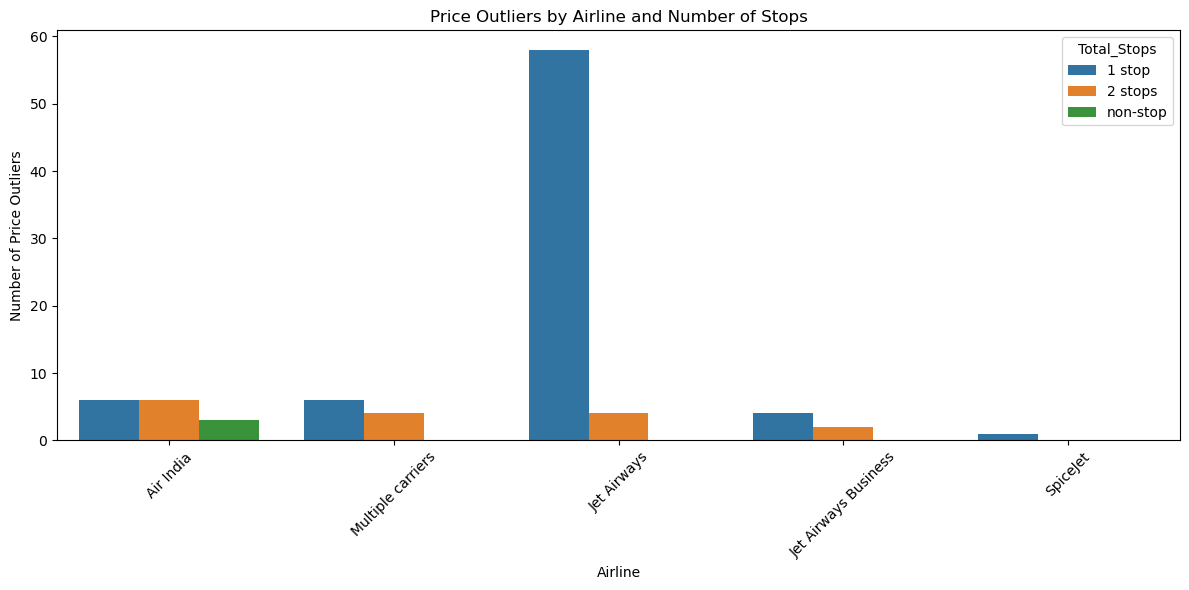

In [66]:
# Step 62: Visualize Price Outliers by Airline and Number of Stops

plt.figure(figsize=(12, 6))

sns.countplot(
    data=price_outliers,
    x='Airline',
    hue='Total_Stops'
)

plt.title('Price Outliers by Airline and Number of Stops')
plt.xlabel('Airline')
plt.ylabel('Number of Price Outliers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
# Step 63: Price Outliers by Departure Period

print("Price Outliers by Departure Period:")

print(
    price_outliers.groupby('Departure_Period')['Price']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Price Outliers by Departure Period:
                  count    min    max          mean
Departure_Period                                   
Morning              46  23267  79512  29792.521739
Night                18  23170  54826  29026.888889
Afternoon            16  24115  54826  31533.437500
Evening              14  23533  54826  33020.785714


In [68]:
# Step 64: Price Outliers by Arrival Period

print("Price Outliers by Arrival Period:")

print(
    price_outliers.groupby('Arrival_Period')['Price']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Price Outliers by Arrival Period:
                count    min    max          mean
Arrival_Period                                   
Night              30  23533  54826  31342.533333
Morning            28  24017  79512  31561.392857
Afternoon          19  23170  62427  29477.000000
Evening            17  23267  36983  27982.823529


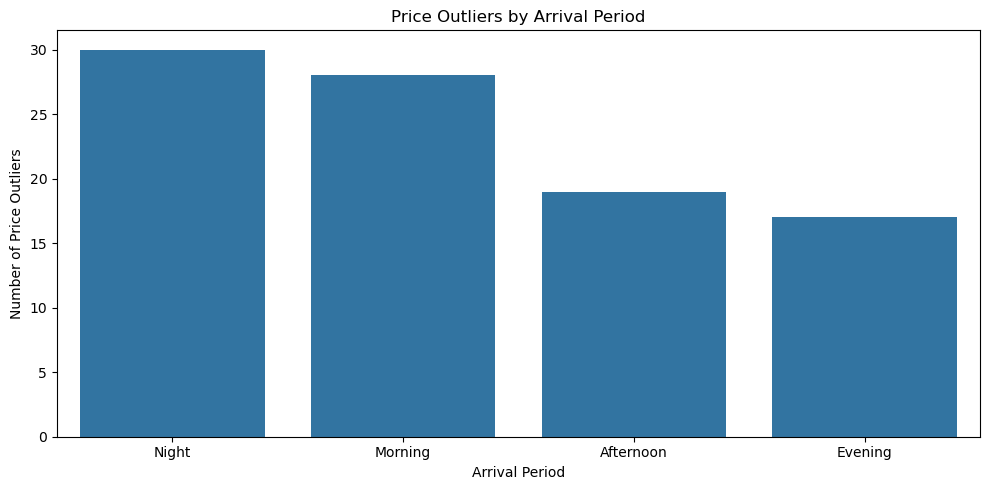

In [69]:
# Step 65: Visualize Price Outliers by Arrival Period

plt.figure(figsize=(10, 5))

sns.countplot(
    data=price_outliers,
    x='Arrival_Period',
    order=price_outliers['Arrival_Period'].value_counts().index
)

plt.title('Price Outliers by Arrival Period')
plt.xlabel('Arrival Period')
plt.ylabel('Number of Price Outliers')

plt.tight_layout()
plt.show()

In [70]:
# Step 66: Summary of Potential Price Outliers

print("Potential Price Outlier Summary:")

print("Number of outliers:", len(price_outliers))

print(
    "Minimum Price:",
    price_outliers['Price'].min(),
    "₹"
)

print(
    "Maximum Price:",
    price_outliers['Price'].max(),
    "₹"
)

print(
    "Average Price:",
    round(price_outliers['Price'].mean(), 2),
    "₹"
)

print("\nOutliers by Airline:")
print(price_outliers['Airline'].value_counts())

print("\nOutliers by Total Stops:")
print(price_outliers['Total_Stops'].value_counts())

Potential Price Outlier Summary:
Number of outliers: 94
Minimum Price: 23170 ₹
Maximum Price: 79512 ₹
Average Price: 30423.04 ₹

Outliers by Airline:
Airline
Jet Airways             62
Air India               15
Multiple carriers       10
Jet Airways Business     6
SpiceJet                 1
Name: count, dtype: int64

Outliers by Total Stops:
Total_Stops
1 stop      75
2 stops     16
non-stop     3
Name: count, dtype: int64


In [71]:
# Step 67: Detailed Inspection of Price Outliers

print("Detailed Price Outlier Inspection:")

display(
    price_outliers[
        ['Airline', 'Source', 'Destination',
         'Total_Stops', 'Duration', 'Duration_Minutes', 'Price']
    ].sort_values('Price', ascending=False)
)

Detailed Price Outlier Inspection:


,Airline,Source,Destination,Total_Stops,Duration,Duration_Minutes,Price
2924,Jet Airways Business,Banglore,New Delhi,1 stop,5h 40m,340,79512
5372,Jet Airways Business,Banglore,New Delhi,1 stop,6h 40m,400,62427
10364,Jet Airways Business,Banglore,New Delhi,1 stop,4h 40m,280,57209
1478,Jet Airways,Banglore,New Delhi,1 stop,6h 5m,365,54826
5439,Jet Airways,Banglore,New Delhi,1 stop,6h 5m,365,54826
...,...,...,...,...,...,...,...
1196,Multiple carriers,Delhi,Cochin,2 stops,7h 45m,465,23583
1341,Multiple carriers,Delhi,Cochin,1 stop,6h 35m,395,23533
8990,Jet Airways,Mumbai,Hyderabad,2 stops,10h 5m,605,23528
5136,SpiceJet,Banglore,New Delhi,1 stop,7h 55m,475,23267


In [72]:
# Step 68: Price Outliers by Route

print("Price Outliers by Route:")

print(
    price_outliers.groupby(
        ['Source', 'Destination', 'Total_Stops']
    )['Price']
    .agg(['count', 'min', 'max', 'mean'])
    .sort_values('count', ascending=False)
)

Price Outliers by Route:
                                  count    min    max          mean
Source   Destination Total_Stops                                   
Banglore New Delhi   1 stop          65  23267  79512  31148.476923
Delhi    Cochin      1 stop          10  23170  36983  27885.600000
                     2 stops          6  23583  52285  35999.500000
Banglore New Delhi   2 stops          5  25430  31783  27173.200000
Mumbai   Hyderabad   2 stops          5  23528  25139  24167.000000
Banglore New Delhi   non-stop         2  25703  25913  25808.000000
Kolkata  Banglore    non-stop         1  31945  31945  31945.000000


In [73]:
# Step 69: Prepare Features for Flight Price Prediction

print("Preparing features for the predictive model...")

# Create a copy of the cleaned dataset
model_df = df.copy()

# Display current columns
print("Current columns:")
print(model_df.columns.tolist())

# Remove columns that are not required for the model
columns_to_drop = ['Route', 'Additional_Info', 'Duration']

# Drop only columns that exist in the dataset
model_df = model_df.drop(
    columns=[col for col in columns_to_drop if col in model_df.columns],
    errors='ignore'
)

print("\nColumns after removing unnecessary features:")
print(model_df.columns.tolist())

print("\nDataset shape:", model_df.shape)

display(model_df.head())

Preparing features for the predictive model...
Current columns:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Departure_Period', 'Arrival_Period', 'Duration_Minutes']

Columns after removing unnecessary features:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Dep_Time', 'Arrival_Time', 'Total_Stops', 'Price', 'Departure_Period', 'Arrival_Period', 'Duration_Minutes']

Dataset shape: (10462, 11)


,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Total_Stops,Price,Departure_Period,Arrival_Period,Duration_Minutes
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,non-stop,3897,Night,Night,170
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,2 stops,7662,Morning,Afternoon,445
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,2 stops,13882,Morning,Night,1140
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,1 stop,6218,Evening,Night,325
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,1 stop,13302,Afternoon,Night,285


In [75]:
# Step 70: Feature Engineering

print("Starting feature engineering...")

# Make a copy
model_df = model_df.copy()

# Convert Date_of_Journey to datetime
model_df['Date_of_Journey'] = pd.to_datetime(
    model_df['Date_of_Journey'],
    dayfirst=True,
    errors='coerce'
)

# Extract useful date features
model_df['Journey_Day'] = model_df['Date_of_Journey'].dt.day
model_df['Journey_Month'] = model_df['Date_of_Journey'].dt.month

# Extract departure hour and minute
model_df['Dep_Hour'] = (
    model_df['Dep_Time']
    .str.extract(r'(\d{1,2}):(\d{2})')[0]
    .astype(int)
)

model_df['Dep_Minute'] = (
    model_df['Dep_Time']
    .str.extract(r'(\d{1,2}):(\d{2})')[1]
    .astype(int)
)

# Extract arrival hour and minute
# Handles values such as "04:25" and "04:25 10 Jun"
model_df['Arrival_Hour'] = (
    model_df['Arrival_Time']
    .str.extract(r'(\d{1,2}):(\d{2})')[0]
    .astype(int)
)

model_df['Arrival_Minute'] = (
    model_df['Arrival_Time']
    .str.extract(r'(\d{1,2}):(\d{2})')[1]
    .astype(int)
)

# Drop original date/time columns
model_df.drop(
    columns=[
        'Date_of_Journey',
        'Dep_Time',
        'Arrival_Time'
    ],
    inplace=True
)

print("\nFeature engineering completed successfully.")

print("\nDataset shape:", model_df.shape)

print("\nColumns after feature engineering:")
print(model_df.columns.tolist())

display(model_df.head())

Starting feature engineering...

Feature engineering completed successfully.

Dataset shape: (10462, 14)

Columns after feature engineering:
['Airline', 'Source', 'Destination', 'Total_Stops', 'Price', 'Departure_Period', 'Arrival_Period', 'Duration_Minutes', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute']


,Airline,Source,Destination,Total_Stops,Price,Departure_Period,Arrival_Period,Duration_Minutes,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,non-stop,3897,Night,Night,170,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,2 stops,7662,Morning,Afternoon,445,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,2 stops,13882,Morning,Night,1140,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,1 stop,6218,Evening,Night,325,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,1 stop,13302,Afternoon,Night,285,1,3,16,50,21,35


In [76]:
# Step 71: Separate Features and Target

print("Separating features and target variable...")

# Target variable
y = model_df['Price']

# Features
X = model_df.drop(columns=['Price'])

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nTarget variable:")
print("Price")

print("\nFeature columns:")
print(X.columns.tolist())

# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain-Test Split Completed")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Separating features and target variable...
Features (X) shape: (10462, 13)
Target (y) shape: (10462,)

Target variable:
Price

Feature columns:
['Airline', 'Source', 'Destination', 'Total_Stops', 'Departure_Period', 'Arrival_Period', 'Duration_Minutes', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute']

Train-Test Split Completed
X_train shape: (8369, 13)
X_test shape: (2093, 13)
y_train shape: (8369,)
y_test shape: (2093,)


In [77]:
# Step 72: Preprocessing Categorical and Numerical Features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

print("Preparing preprocessing pipeline...")

# Identify categorical columns
categorical_features = [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops',
    'Departure_Period',
    'Arrival_Period'
]

# Identify numerical columns automatically
numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

print("\nPreprocessing pipeline created successfully.")

Preparing preprocessing pipeline...
Categorical features:
['Airline', 'Source', 'Destination', 'Total_Stops', 'Departure_Period', 'Arrival_Period']

Numerical features:
['Duration_Minutes', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute']

Preprocessing pipeline created successfully.


In [78]:
# Step 73: Transform Training and Testing Data

print("Transforming training and testing data...")

# Fit on training data and transform training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Transformation completed successfully.")

print("\nOriginal X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Transforming training and testing data...
Transformation completed successfully.

Original X_train shape: (8369, 13)
Processed X_train shape: (8369, 42)

Original X_test shape: (2093, 13)
Processed X_test shape: (2093, 42)


In [79]:
# Step 74: Train Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Training Random Forest Regression model...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Training Random Forest Regression model...
Random Forest model trained successfully.


In [80]:
# Step 75: Predict and Evaluate Random Forest Model

print("Making predictions on test data...")

y_pred_rf = rf_model.predict(X_test_processed)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regression - Evaluation Results")
print("-" * 50)
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")

Making predictions on test data...

Random Forest Regression - Evaluation Results
--------------------------------------------------
Mean Absolute Error (MAE): 1166.64
Root Mean Squared Error (RMSE): 1958.37
R² Score: 0.8161


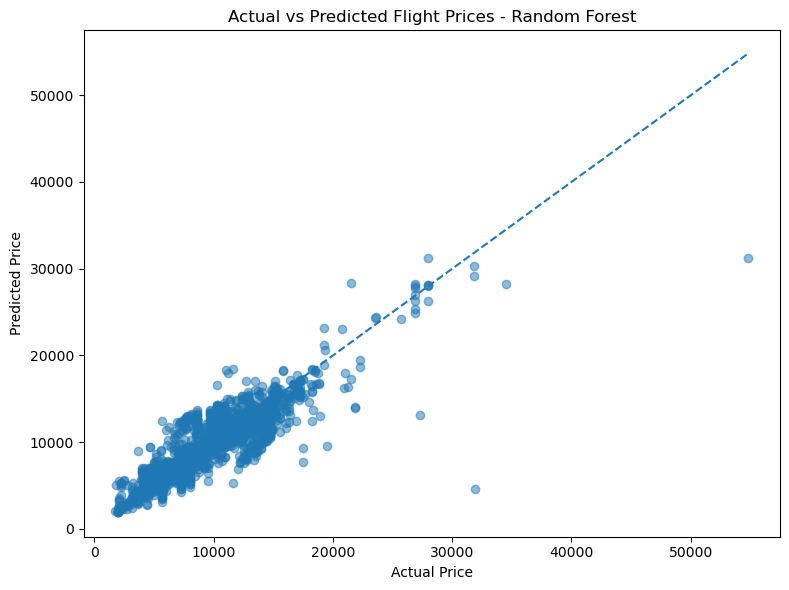

In [81]:
# Step 76: Actual vs Predicted Price Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices - Random Forest")

plt.tight_layout()
plt.show()

In [82]:
# Step 77: Feature Importance Analysis

print("Analyzing feature importance...")

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get importance values from Random Forest
importance_values = rf_model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 15 Important Features:")
display(feature_importance_df.head(15))

Analyzing feature importance...

Top 15 Important Features:


,Feature,Importance
35,remainder__Duration_Minutes,0.453500
36,remainder__Journey_Day,0.130942
5,categorical__Airline_Jet Airways Business,0.075508
4,categorical__Airline_Jet Airways,0.059576
37,remainder__Journey_Month,0.058937
40,remainder__Arrival_Hour,0.027976
23,categorical__Total_Stops_1 stop,0.024078
39,remainder__Dep_Minute,0.024026
38,remainder__Dep_Hour,0.021013
41,remainder__Arrival_Minute,0.019681


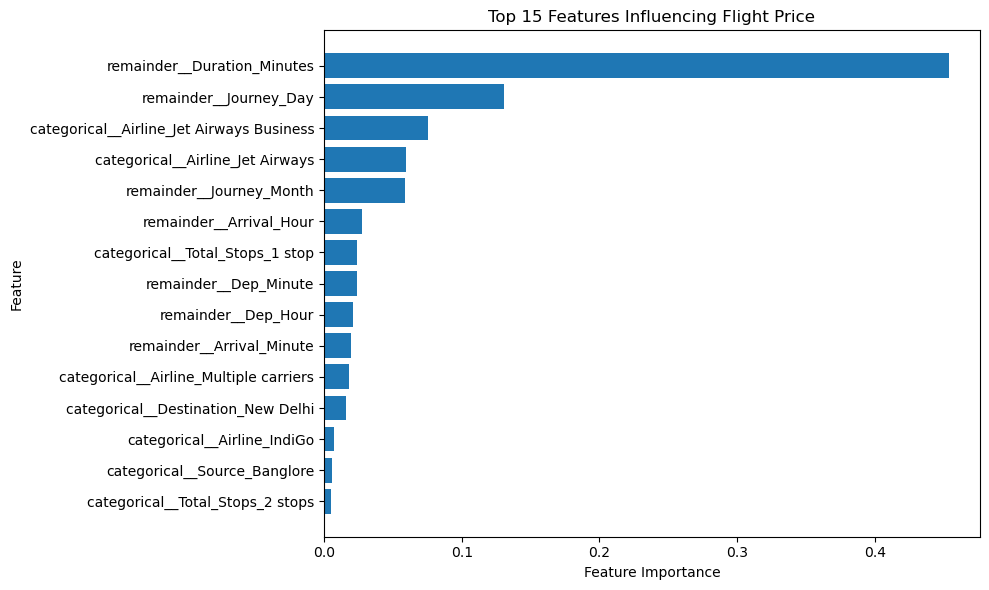

In [83]:
# Step 77B: Visualize Top 15 Feature Importances

top_features = feature_importance_df.head(15).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Flight Price")

plt.tight_layout()
plt.show()

In [85]:
# Step 78: Train Decision Tree Regression Model

from sklearn.tree import DecisionTreeRegressor

print("Training Decision Tree Regression model...")

dt_model = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Training Decision Tree Regression model...
Decision Tree model trained successfully.


In [86]:
# Step 79: Evaluate Decision Tree Regression Model

print("Making predictions using Decision Tree...")

y_pred_dt = dt_model.predict(X_test_processed)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Regression - Evaluation Results")
print("-" * 50)
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R² Score: {r2_dt:.4f}")

Making predictions using Decision Tree...

Decision Tree Regression - Evaluation Results
--------------------------------------------------
Mean Absolute Error (MAE): 1283.07
Root Mean Squared Error (RMSE): 2188.93
R² Score: 0.7702


In [87]:
# Step 80: Compare Regression Models

print("Model Comparison")
print("=" * 60)

model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree'],
    'MAE': [mae_rf, mae_dt],
    'RMSE': [rmse_rf, rmse_dt],
    'R2 Score': [r2_rf, r2_dt]
})

display(model_comparison)

Model Comparison


,Model,MAE,RMSE,R2 Score
0,Random Forest,1166.636268,1958.373994,0.816059
1,Decision Tree,1283.074388,2188.928283,0.770199


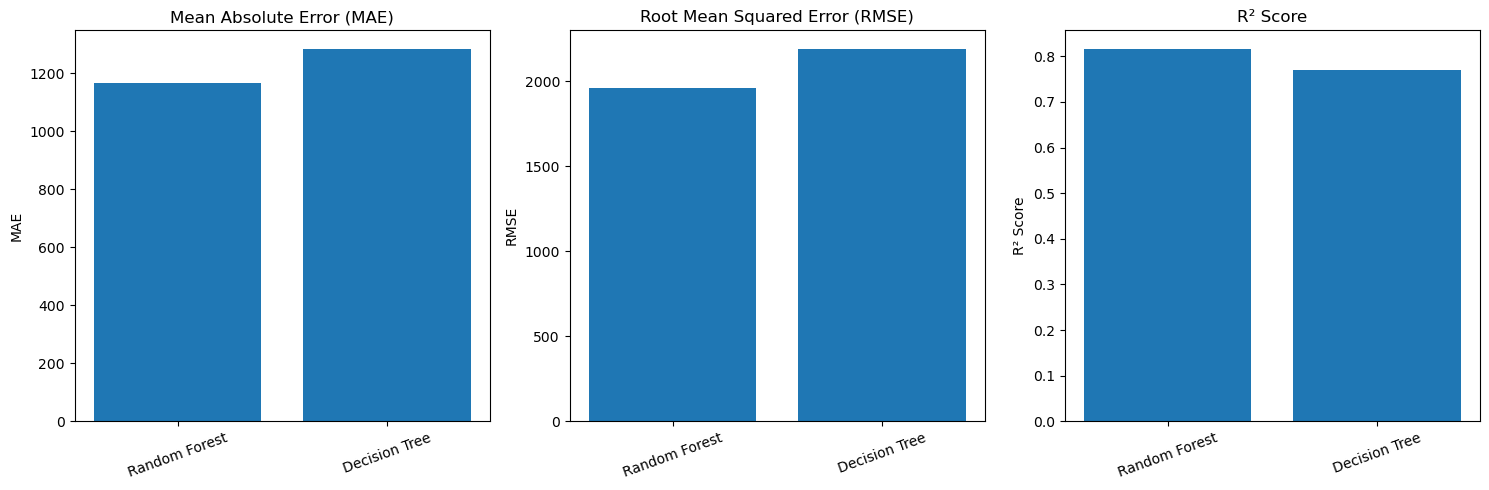

In [88]:
# Step 81: Visualize Model Performance

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE
axes[0].bar(model_comparison['Model'], model_comparison['MAE'])
axes[0].set_title('Mean Absolute Error (MAE)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=20)

# RMSE
axes[1].bar(model_comparison['Model'], model_comparison['RMSE'])
axes[1].set_title('Root Mean Squared Error (RMSE)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)

# R2
axes[2].bar(model_comparison['Model'], model_comparison['R2 Score'])
axes[2].set_title('R² Score')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Model Comparison Report

Two regression models, Random Forest and Decision Tree, were developed and
evaluated for flight price prediction using MAE, RMSE, and R² Score.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Random Forest | 1166.64 | 1958.37 | 0.8161 |
| Decision Tree | 1283.07 | 2188.93 | 0.7702 |

The Random Forest model produced an MAE of 1166.64, RMSE of 1958.37, and
R² Score of 0.8161.

The Decision Tree model produced an MAE of 1283.07, RMSE of 2188.93, and
R² Score of 0.7702.

Based on the evaluation results obtained on the test dataset, the Random
Forest model is selected as the final model for production because it
achieved lower MAE and RMSE and a higher R² Score than the Decision Tree
model.

Therefore, Random Forest will be considered the final model for the flight
price prediction task.

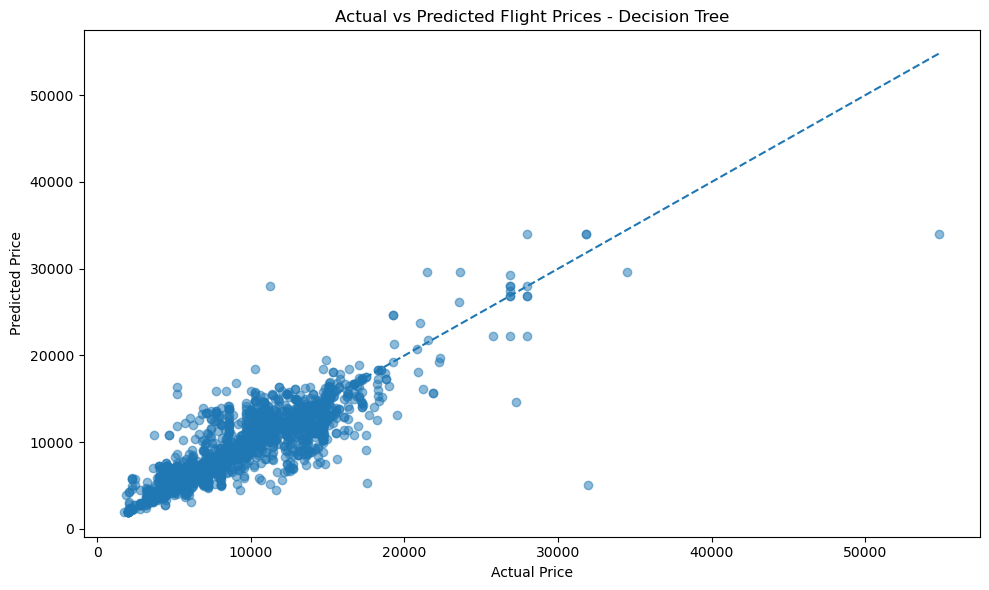

In [89]:
# Step 83: Actual vs Predicted Flight Prices - Decision Tree

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_dt, alpha=0.5)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_dt.min())
max_price = max(y_test.max(), y_pred_dt.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Flight Prices - Decision Tree')

plt.tight_layout()
plt.show()

In [90]:
# Step 84: Final Model Summary

print("Final Model Summary")
print("=" * 60)

print(f"Random Forest - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")
print(f"Decision Tree  - MAE: {mae_dt:.2f}, RMSE: {rmse_dt:.2f}, R²: {r2_dt:.4f}")

Final Model Summary
Random Forest - MAE: 1166.64, RMSE: 1958.37, R²: 0.8161
Decision Tree  - MAE: 1283.07, RMSE: 2188.93, R²: 0.7702


# Final Project Conclusion

The Flight Fare Prediction project involved data cleaning, exploratory data
analysis, feature engineering, preprocessing, and predictive modeling.

The dataset was analyzed to identify important factors affecting flight
prices, including airline, source, destination, number of stops, journey
date, departure period, arrival period, and journey duration.

Two regression models, Random Forest and Decision Tree, were developed and
evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE),
and R² Score.

The Random Forest model obtained an MAE of 1166.64, an RMSE of 1958.37,
and an R² Score of 0.8161. The Decision Tree model obtained an MAE of
1283.07, an RMSE of 2188.93, and an R² Score of 0.7702.

The results demonstrate that machine learning can be used to estimate
flight prices from the available flight-related features. The analysis
also provides insights into the factors associated with variations in
flight fares.

# Suggestions and Recommendations

1. Flight prices should be analyzed based on airline, route, number of
   stops, departure period, arrival period, and journey duration.

2. Historical flight-price data can be continuously collected to improve
   future prediction models.

3. Data preprocessing and feature engineering should be performed
   carefully because categorical and time-related variables contain
   important information for flight-price prediction.

4. Outliers and unusual flight prices should be investigated before
   training the model to understand whether they represent genuine
   high-priced flights or data-quality issues.

5. The trained prediction model can be integrated into a flight-booking
   or price-analysis application to provide estimated fares to users.

6. Periodic model retraining can be performed as new flight-price data
   becomes available.

# Report on Challenges Faced

During the Flight Fare Prediction project, several challenges were encountered while performing data analysis and building the predictive models.

1. **Data Cleaning:** The dataset contained different formats and values in some columns, particularly date and time-related features. These required proper preprocessing before analysis and modeling.

2. **Handling Date and Time Features:** Extracting useful information such as journey day, journey month, departure hour, departure minute, arrival hour, and arrival minute required careful conversion of the original date/time columns.

3. **Inconsistent Time Formats:** Some values in the `Arrival_Time` column contained additional date information along with the time. This initially caused a conversion error while extracting the arrival minute. The issue was resolved by appropriately separating the time component before converting it into numerical values.

4. **Categorical Variables:** Features such as `Airline`, `Source`, `Destination`, `Total_Stops`, `Departure_Period`, and `Arrival_Period` were categorical. One-hot encoding was required to convert these variables into a suitable numerical format for machine learning.

5. **Outlier Detection:** Several unusually high flight prices were identified. A total of **94 potential price outliers** were detected, with prices ranging from **₹23,170 to ₹79,512**. These observations required additional investigation rather than being automatically removed.

6. **Feature Engineering:** New features such as journey day, journey month, departure hour/minute, arrival hour/minute, and duration in minutes were created to improve the model's ability to learn relationships between flight characteristics and price.

7. **Model Evaluation:** The Random Forest and Decision Tree regression models were evaluated using MAE, RMSE, and R² Score to understand their predictive performance.

8. **Debugging:** During the Decision Tree evaluation, a `NameError` occurred because `dt_model` was not defined in the current notebook execution state. The issue was resolved and the model evaluation was completed successfully.

### Overall

Despite these challenges, the data preprocessing, feature engineering, visualization, and predictive modeling stages were successfully completed. The project provided useful insights into the factors associated with flight fare variation and demonstrated the application of machine learning for flight price prediction.